In [112]:
from pathlib import Path
from typing import Dict, List, Tuple
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
import xarray as xr

from model_tuner.opt.regimes import (
    NetRegimeWC, NetRegimeWCList,
    NetRegime1DList
)
from model_tuner.opt.ir_mappers import NetIRMapperWC
from model_tuner.opt.uc_mappers import NetUCMapper1D
from model_tuner.opt.wc import ModelDescWC
from model_tuner.opt.wc import wc_gain, run_wc_model

from model_tuner.main import UCMapFitParams, init_uc_mapper
from model_tuner.utils import load_yaml

warnings.filterwarnings('ignore')

In [113]:
def fit_uc_mapper(
        Ru_lst: NetRegime1DList,
        Rc_lst: NetRegime1DList,
        uc_map_params: UCMapFitParams
        ) -> NetUCMapper1D:
    
    uc_mapper = init_uc_mapper(uc_map_params)
    uc_mapper.fit_from_data(
        Ru_lst, Rc_lst,
        fit_params=uc_map_params.map_fit_params,
        bounds=uc_map_params.fit_param_bounds,
        verbose=False
    )
    return uc_mapper

In [114]:
def uc_fit_step_to_latest(
        Ru_data: xr.DataArray,   # pop x pfr x iter
        Rc_data: xr.DataArray,   # pop x pfr x iter
        uc_map_params: UCMapFitParams,
        alpha: float = 1,
        ) -> NetUCMapper1D:
    
    Ru_mat = Ru_data.isel(iter=-1, drop=True)

    Rc_mat_last = Rc_data.isel(iter=-1, drop=True)
    Rc_mat_prev = Rc_data.isel(iter=-2, drop=True)
    Rc_mat = alpha * Rc_mat_last + (1 - alpha) * Rc_mat_prev

    Ru_lst = NetRegimeWCList.from_xr(Ru_mat)
    Rc_lst = NetRegimeWCList.from_xr(Rc_mat)

    return fit_uc_mapper(Ru_lst, Rc_lst, uc_map_params)


In [115]:
def init_ru_rc_storage(
        pop_names: List[str],
        pfr_vec: List[float] | np.ndarray,
        niter: int,
        R0_lst: NetRegimeWCList,
        ) -> Tuple[xr.DataArray, xr.DataArray]:

    # Allocate Ru and Rc storage
    Z = np.full((len(pop_names), len(pfr_vec), niter), np.nan)
    Ru_data = xr.DataArray(
        Z.copy(),
        dims=['pop', 'pfr', 'iter'],
        coords={'pop': pop_names,
                'pfr': pfr_vec,
                'iter': np.arange(niter)}
    )
    Rc_data = Ru_data.copy()

    # First iter: identity
    Ru_data.loc[{'iter': 0}] = R0_lst.to_xr('pfr', pfr_vec)
    Rc_data.loc[{'iter': 0}] = R0_lst.to_xr('pfr', pfr_vec)

    return Ru_data, Rc_data

In [116]:
def load_uc_map_params() -> UCMapFitParams:
    # Load UC map params
    dirpath_base = Path(
        r'D:\WORK\Salvador\repo\model_tuner\test_data\main'
        r'\test_opt_A1_hpc_batch_qsub\experiments'
        r'\test_2_pfr=(0.4_1.0_4)_wmult=0.005_alpha=1'
    )
    uc_map_params: UCMapFitParams = load_yaml(
        dirpath_base / 'uc_map_params.yaml',
        data_class=UCMapFitParams
    )
    return uc_map_params

In [117]:
def create_wc_model(
        npops: int,
        nifrac: float = 0.5,   # fraction of inhibitory pops.
        g: float = 1,   # global weight multiplier
        gi: float = 1   # additional inhibitory weight multiplier
        ) -> ModelDescWC:

    npops_i = int(npops * nifrac)

    W = np.random.randn(npops, npops)
    W = np.abs(W) * g
    W[:, -npops_i:] *= -gi

    model = ModelDescWC.create_unconn(num_pops=npops)
    model.conn = W
    
    return model

In [118]:
def plot_rc_data(
        Rc_data: xr.DataArray,
        rr_base: List[float] | np.ndarray,
        pops_vis: List[str] | None = None
        ) -> None:

    pop_names = Rc_data.pop.values
    pfr_vec = Rc_data.pfr.values
    niter = Rc_data.iter.size

    if not pops_vis:
        pops_vis = pop_names
    npops_vis = len(pops_vis)
    
    rr_base = [rr_base[list(pop_names).index(pop)] for pop in pops_vis]

    plt.figure()
    for pop_num, pop in enumerate(pops_vis):
        plt.subplot(1, npops_vis, pop_num + 1)
        for pfr in pfr_vec:
            rc_vec = Rc_data.sel(pop=pop, pfr=pfr).values
            plt.plot(rc_vec, label=f'pfr={pfr:.02f}')
        plt.plot([0, niter], [rr_base[pop_num]] * 2, 'k--')
        #plt.legend()
        plt.xlabel('Iteration')
        if pop_num == 0:
            plt.ylabel('Rc')
        plt.title(pop)

In [119]:
def run_opt_experiment(
        model: ModelDescWC,
        rr_base: float,
        pfr_vec: List[float] | np.ndarray,
        uc_map_params: UCMapFitParams,
        niter: int,
        sim_par: Dict | None = None,
        uc_alpha: float = 1,
        verbose=False
        ) -> Tuple[xr.DataArray, xr.DataArray]:
    
    pop_names = model.get_pop_names()

    # Target regimes (base * pfr for each pfr)
    pfr_vec = np.array(pfr_vec)
    R0_lst = NetRegimeWCList(
        [NetRegimeWC.from_rates(pop_names, rr_base * pfr)
         for pfr in pfr_vec]
    )

    # Allocate Ru and Rc storage, set the 1-st iter to identity
    Ru_data, Rc_data = init_ru_rc_storage(
        pop_names, pfr_vec, niter, R0_lst
    )
    
    # I-R mapper, explicitly uses WC gain functions
    ir_mapper = NetIRMapperWC(model)

    # Initialize UC mapper
    uc_mapper = init_uc_mapper(uc_map_params)

    # Parameters of WC "simulation"
    if sim_par is None:
        sim_par = {'niter': 20, 'dr_mult': 1}

    for iter_num in tqdm(range(1, niter), desc='Optimization'):
        if verbose:
            print(f'Iter: {iter_num}')

        # Rc0 -> Ru
        Ru_lst = uc_mapper.Rc_to_Ru(R0_lst)
        NetRegimeWCList._convert_parent(Ru_lst)

        Rc_lst = NetRegimeWCList()
        for n, Ru in enumerate(Ru_lst):
            # Ru -> Iu
            Iu = ir_mapper.R_to_I(Ru)
            # Run model with Iu and get Rc
            Rc, sim_info = run_wc_model(
                model, Iu, sim_par['niter'], Ru, sim_par['dr_mult']
            )
            Rc_lst.append(Rc)
        
        # Store Ru and Rc data
        Ru_data.loc[{'iter': iter_num}] = Ru_lst.to_xr('pfr', pfr_vec)
        Rc_data.loc[{'iter': iter_num}] = Rc_lst.to_xr('pfr', pfr_vec)
        
        # Fit UC mapping
        try:
            uc_mapper = uc_fit_step_to_latest(
                Ru_data.sel(iter=range(0, iter_num + 1)),
                Rc_data.sel(iter=range(0, iter_num + 1)),
                uc_map_params,
                alpha=uc_alpha
            )
        except Exception as e:
            print(f'Optimization failed: {e}')
            break

    return Ru_data, Rc_data


Optimization:   0%|          | 0/9 [00:00<?, ?it/s]

Optimization failed: All-NaN slice encountered


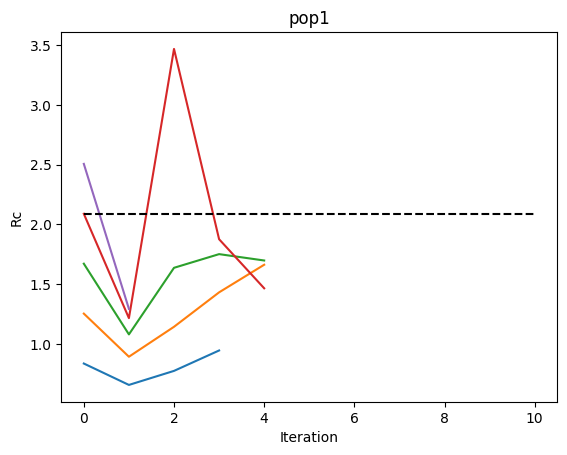

In [120]:
# WC model
model = create_wc_model(npops=6, g=0.25)

# Original target rate vector
rmin, rmax = 1, 6
rr_base = rmin + (rmax - rmin) * np.random.rand(model.npops)

# Target regime multipliers
pfr_vec = np.array([0.4, 0.6, 0.8, 1, 1.2])

# Parameters of WC "simulation"
sim_par = {'niter': 20, 'dr_mult': 1}

# UC map params
uc_map_params = load_uc_map_params()
uc_map_params.pop_names = model.get_pop_names()

Ru_data, Rc_data = run_opt_experiment(
    model, rr_base, pfr_vec,uc_map_params,
    niter=10, uc_alpha=0.7
)

plot_rc_data(Rc_data, rr_base, pops_vis=['pop1'])